In [4]:
%matplotlib widget
from lines import REDUC_LINES
from corr import REDSHIFT, SPECTRALDATA, CONTINUUM_SUBSTRACT

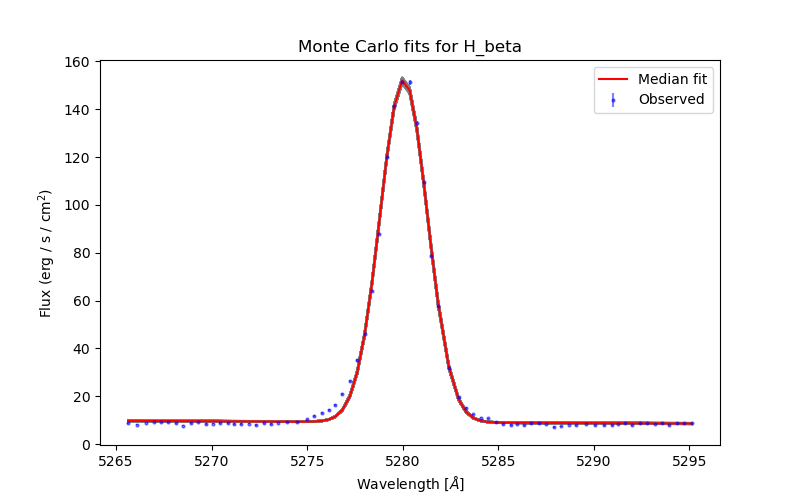

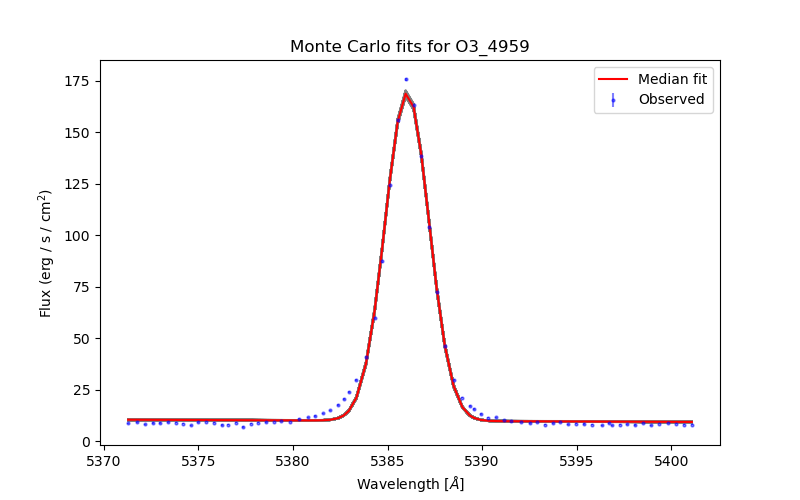

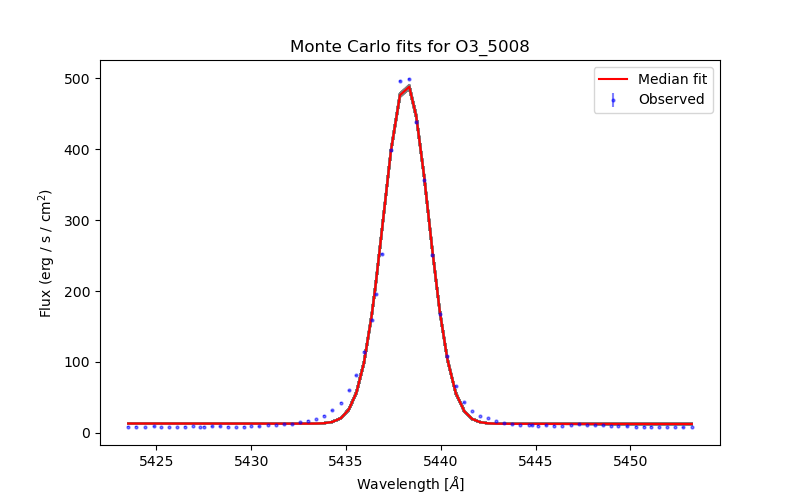

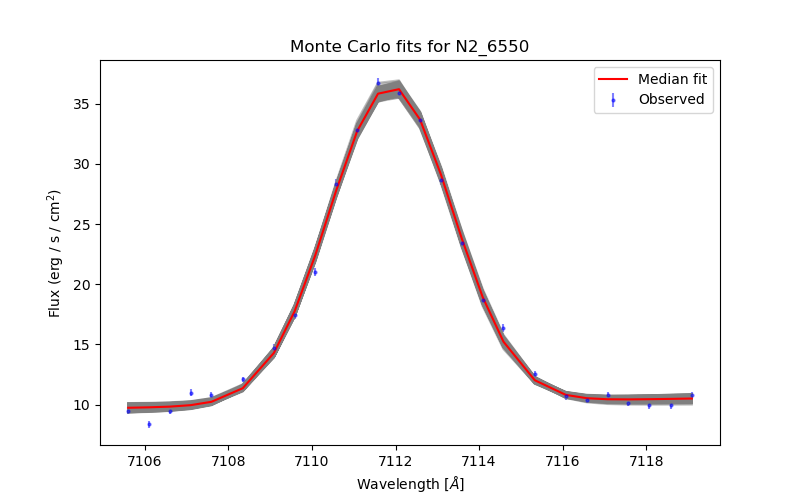

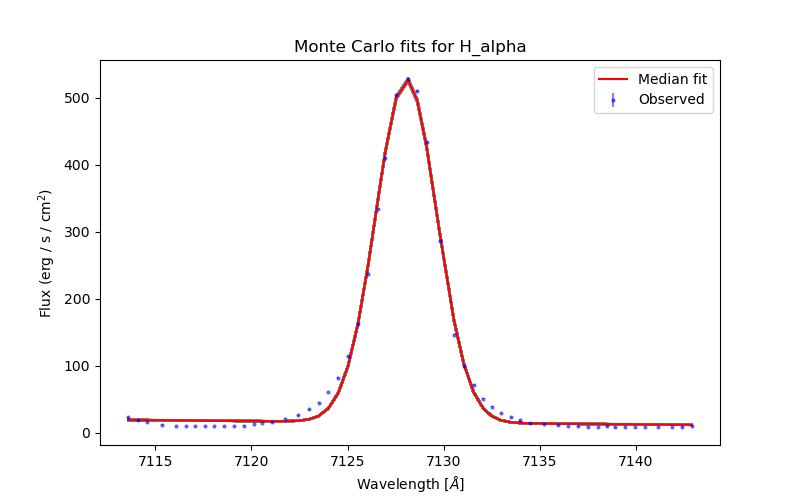

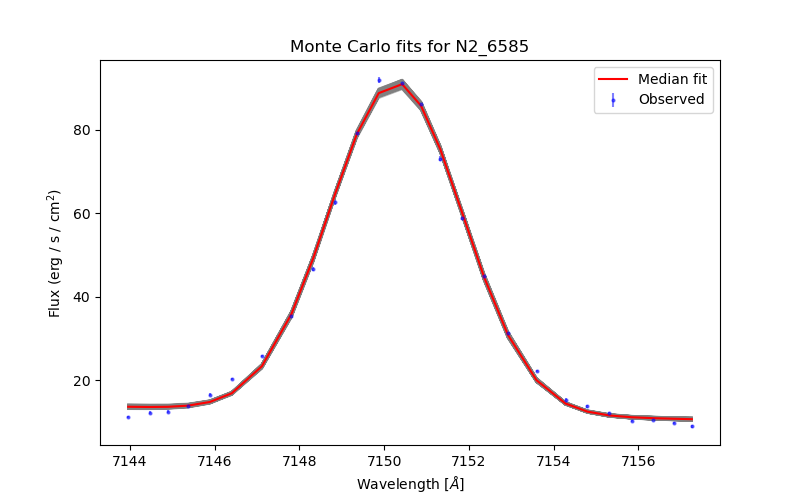

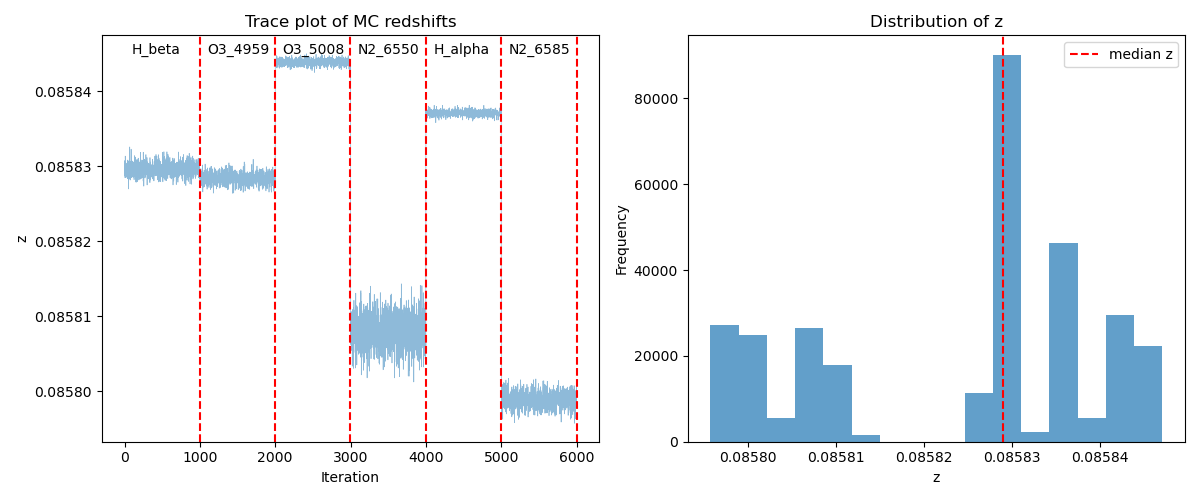

New redshift calculated for no_very_flats,z = 0.08582893859024499
Executed reset_redshift in 37.9793s
New redshift for J0328+0031,z = 0.08582893859024499


In [5]:
J0328_SPECTRA= {
    'DIR':'/Users/javieratoro/Desktop/thesis/BAADE_DATA/testing/35-J0328/',
    'FILES': ['no_very_flats/J0328_NO_VERY_FLATS_tellcorr.fits'],# 'twilight/J0243_TWILIGHT_tellcorr.fits'],
     'redshift': 0.086,
     'names':['J0328+0031'],
     'mass':9.8
}
J0328 = SPECTRALDATA(J0328_SPECTRA)
Z = REDSHIFT(J0328)

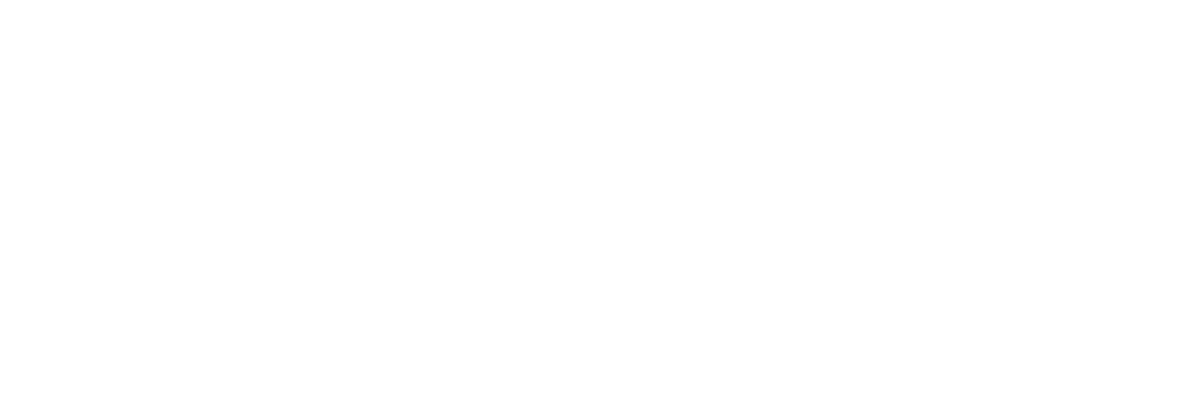

In [ ]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"


plt.figure(figsize=(12, 4))
pandas

plt.show()

Performing dust correction for J0328
Extinction correction done! Using total curve.


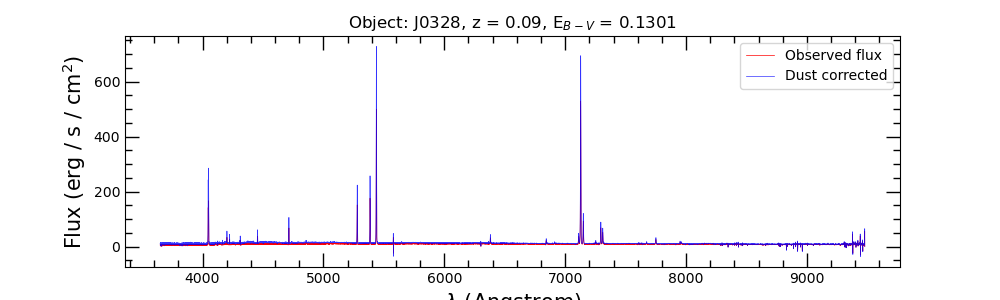

Saved figure at: /Users/javieratoro/Desktop/thesis/proyecto 2024-2/dust/J0328/dcorr_J0328.pdf
Using uncorrected data


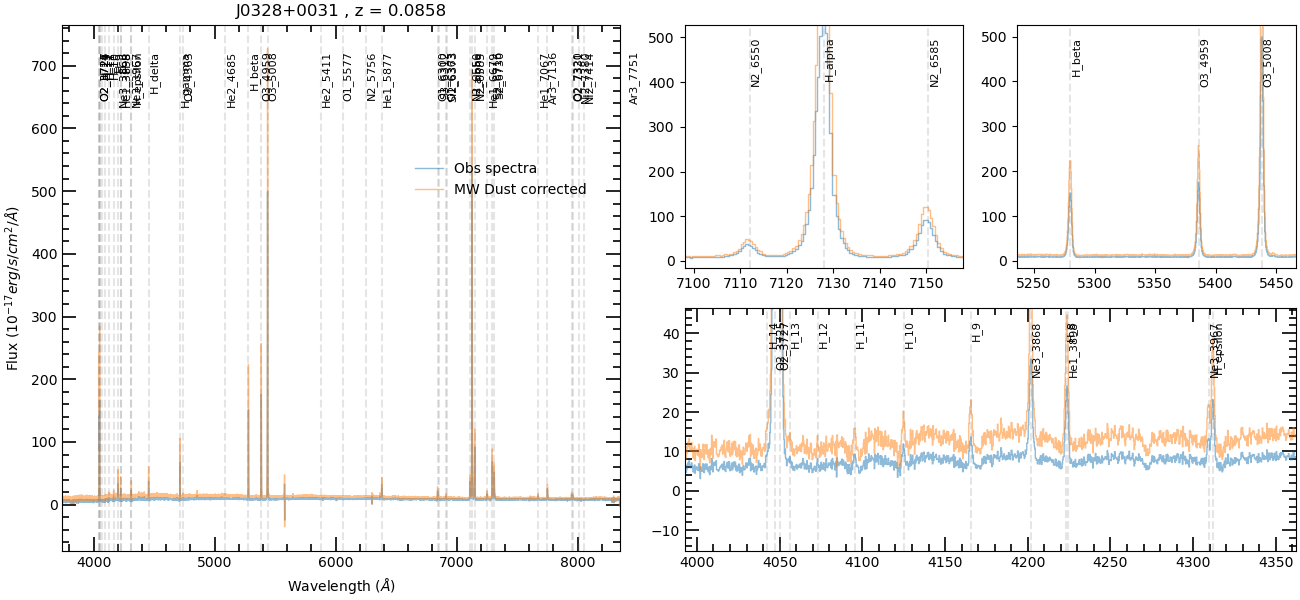

Saved MW dust corrected data to: /Users/javieratoro/Desktop/thesis/proyecto 2024-2/dust/J0328/dcorr_J0328.csv
Executed MW_dust_corr in 0.8232s


In [6]:
MW_DUST_CORR(J0328)

Reading data for J0328
Using MW dust corrected data
Performing Balmer absorption correction for J0328


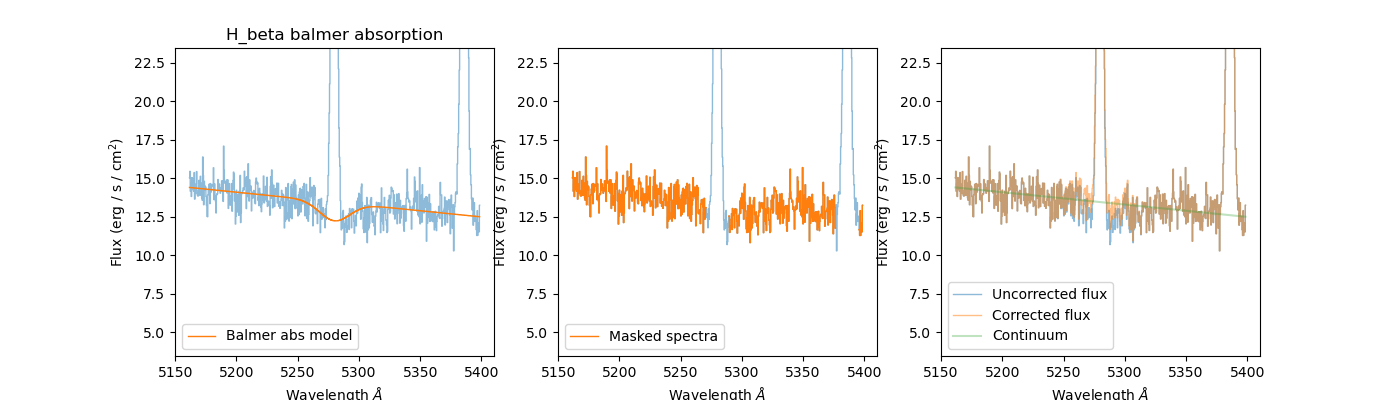

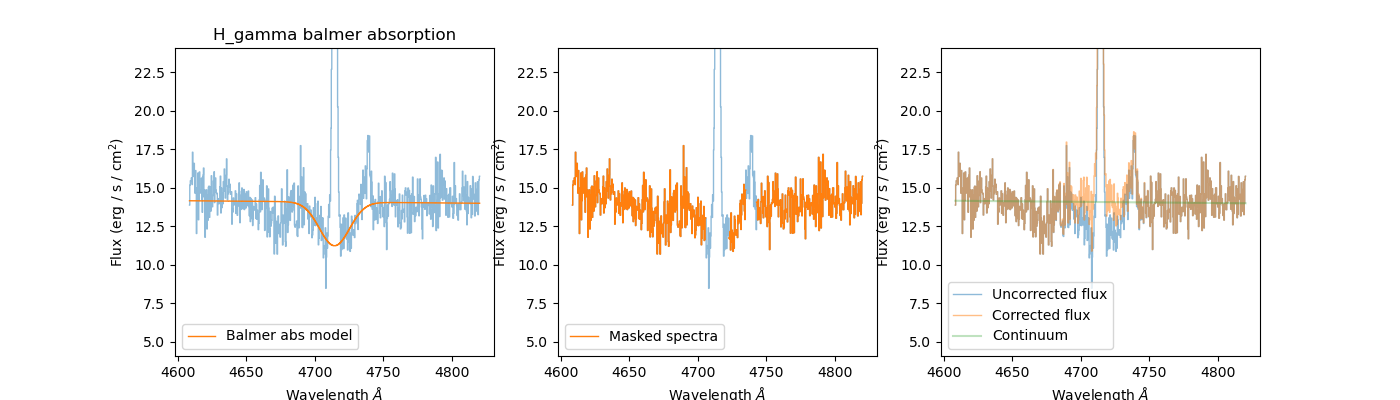

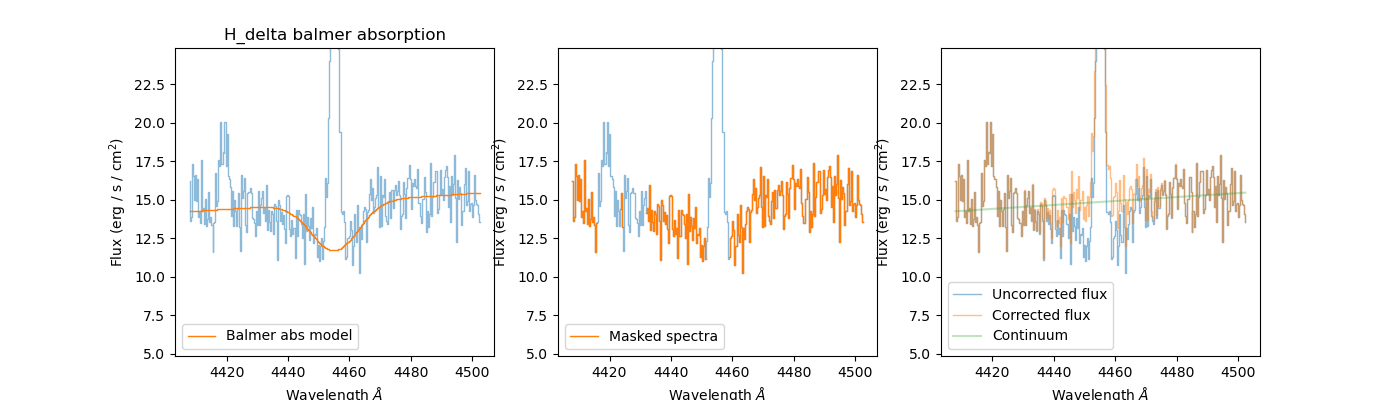

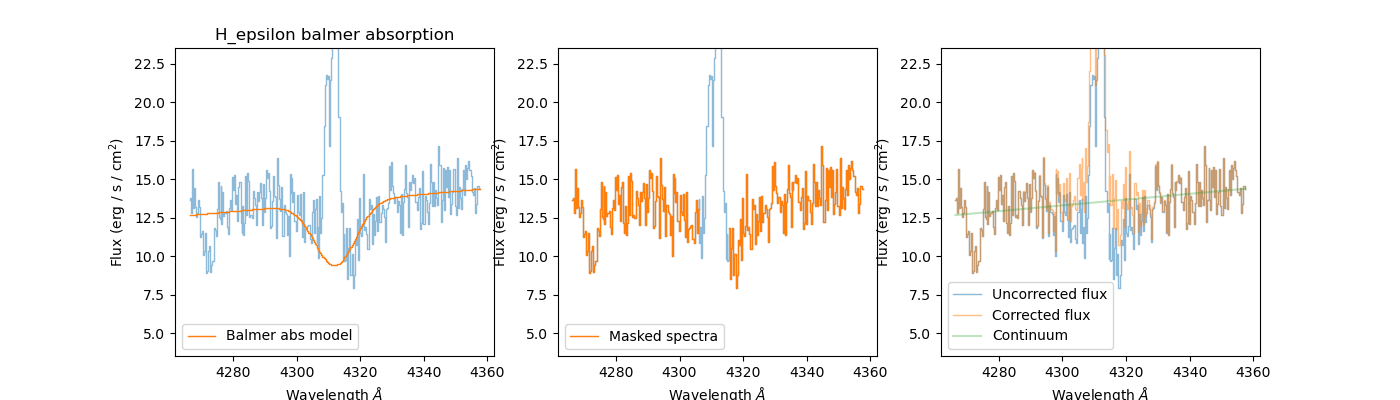

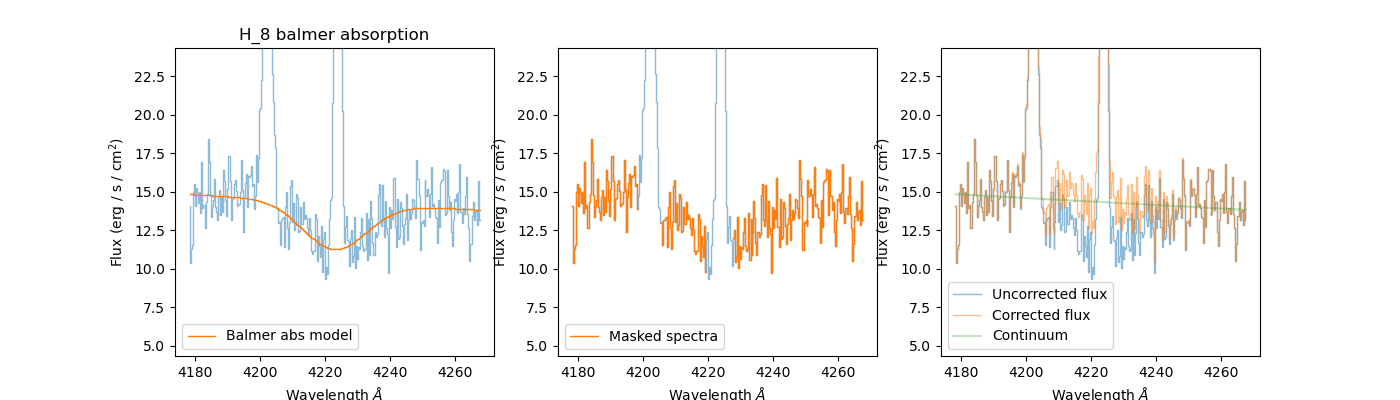

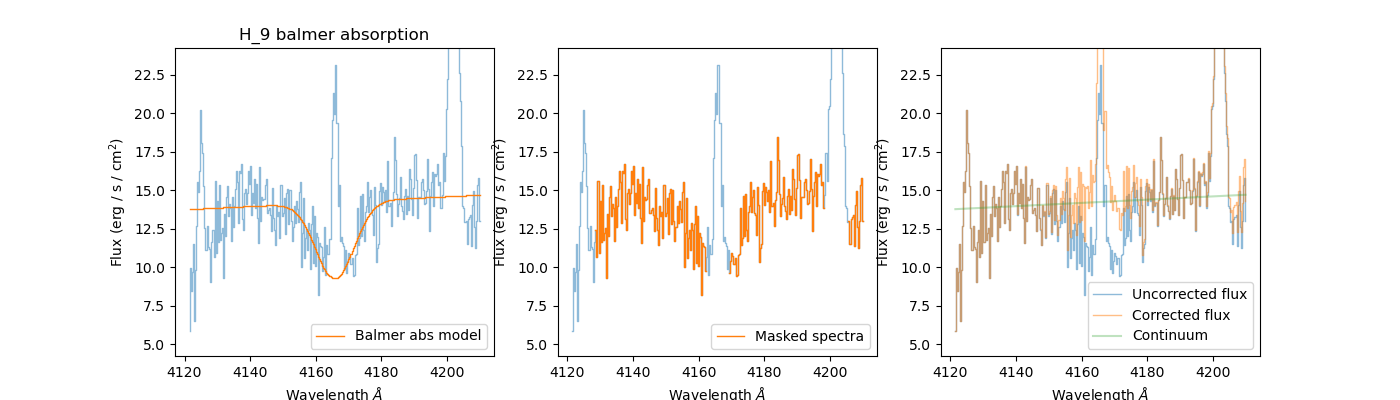

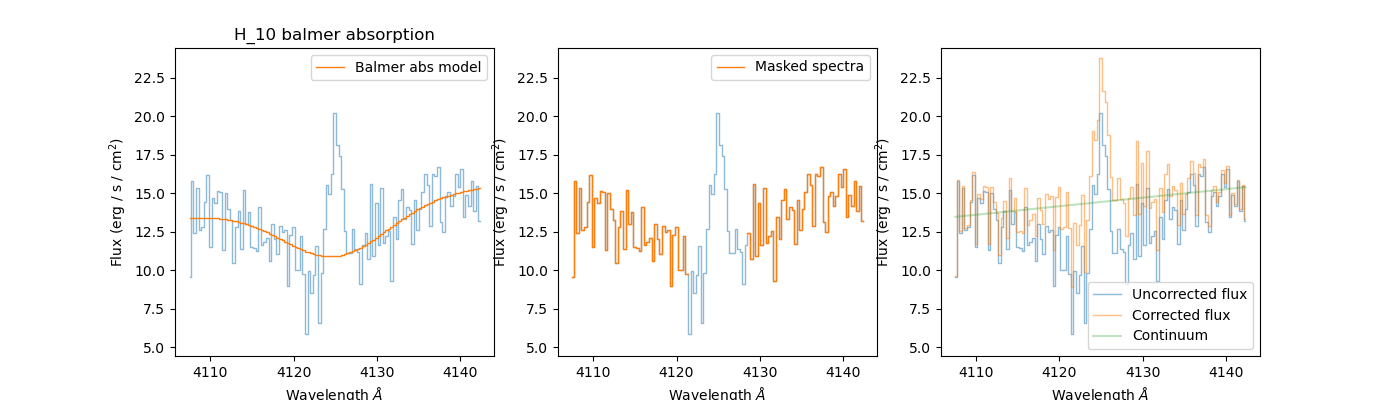

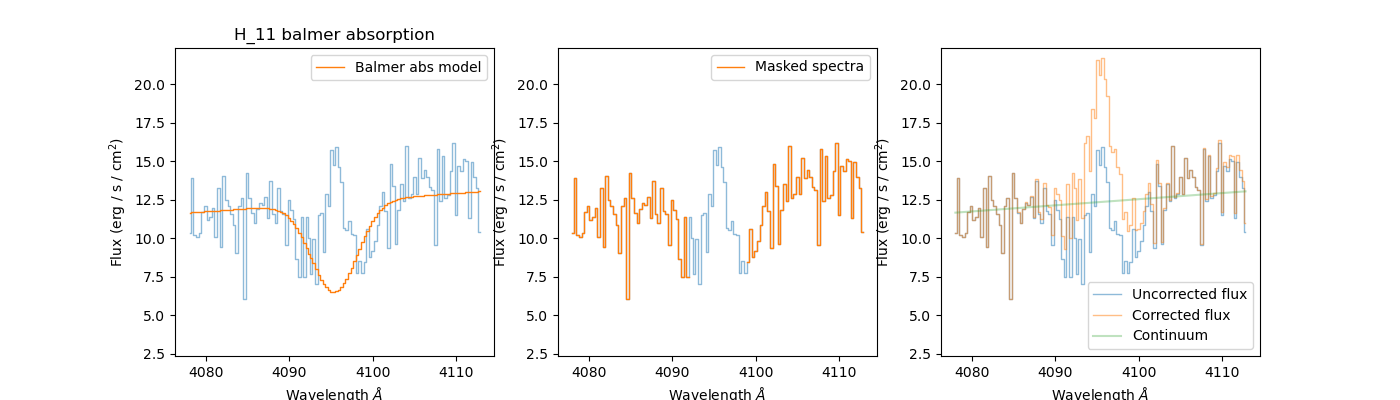

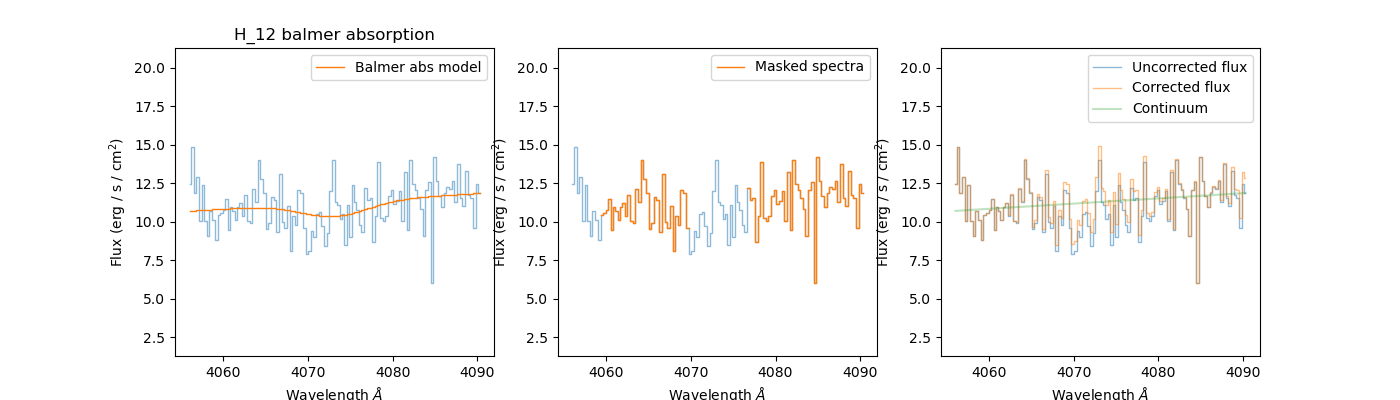

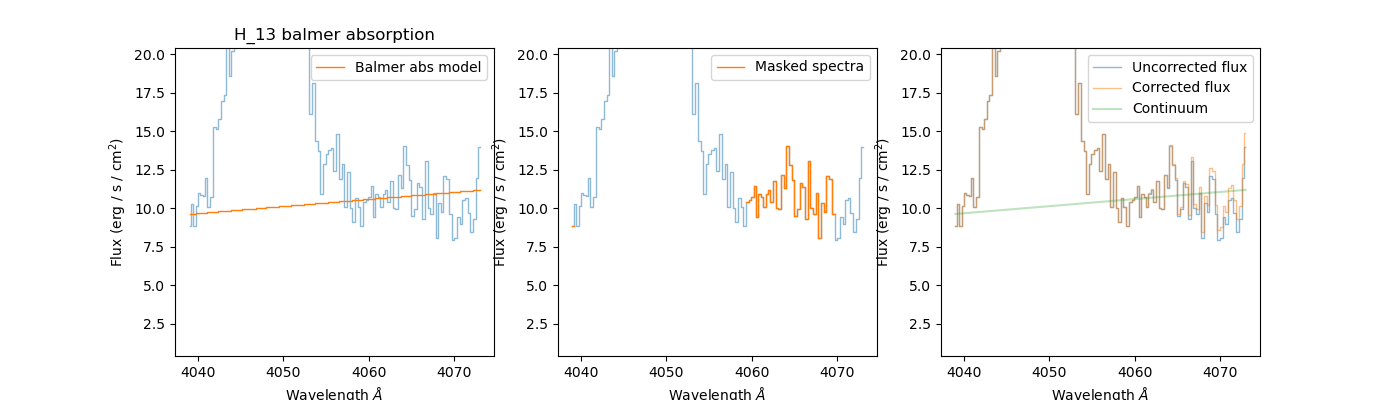

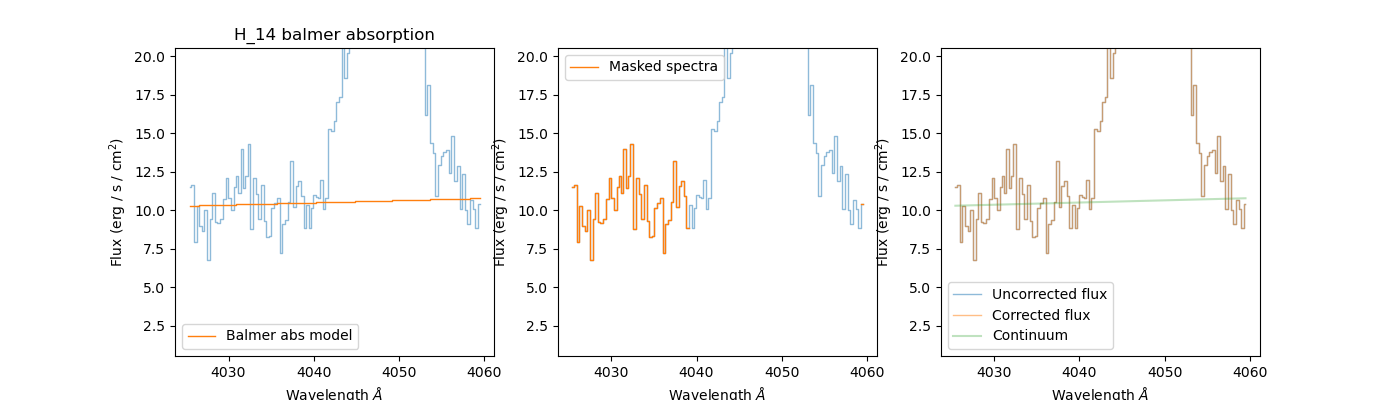

Using MW dust + Balmer abs corrected and continuum substracted data


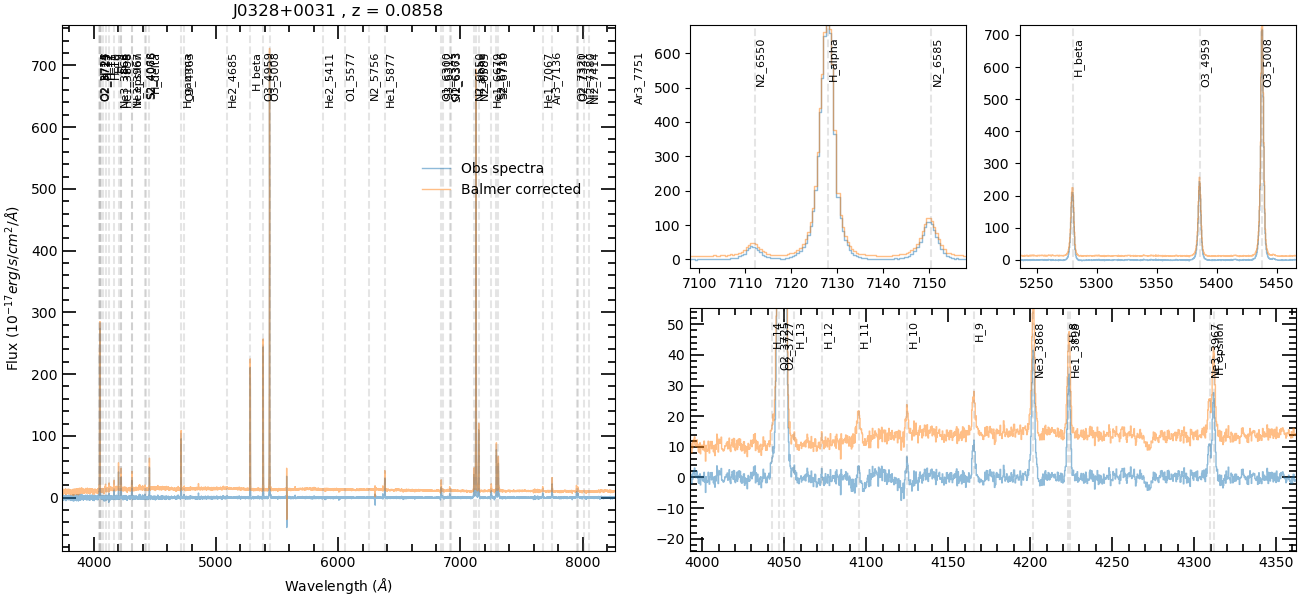

Saved Balmer Absorption corrected data to: /Users/javieratoro/Desktop/thesis/proyecto 2024-2/bal_abs/bcorr_J0328.csv
Balmer absorption correction done!
Executed bal_abs_corr in 3.4046s


In [15]:
b = BALMER_ABS(J0328, showplot=True)

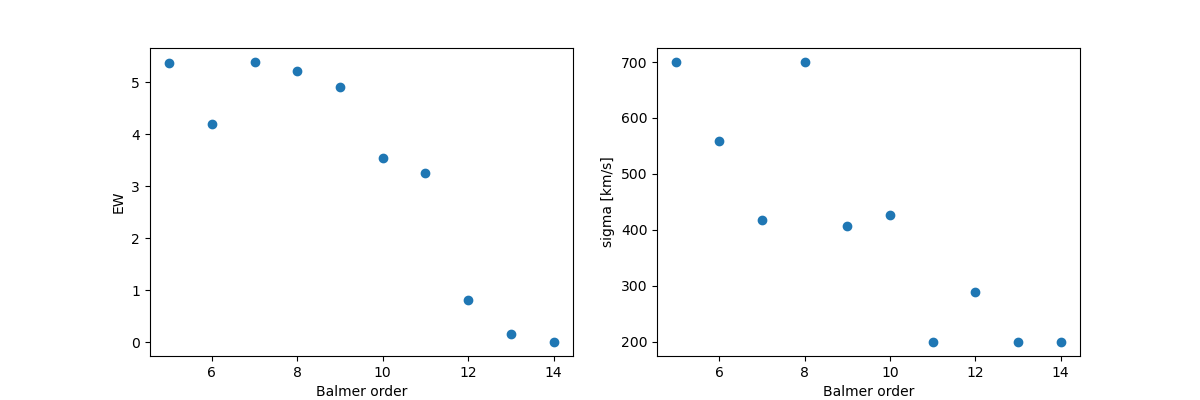

,ID,z,name,sigma,EW
0,J0328+0031,0.085829,H_beta,700.000000,-2.823296
1,J0328+0031,0.085829,H_gamma,700.000000,-5.379608
2,J0328+0031,0.085829,H_delta,558.389331,-4.203710
3,J0328+0031,0.085829,H_epsilon,417.109595,-5.393521
4,J0328+0031,0.085829,H_8,700.000000,-5.210654
5,J0328+0031,0.085829,H_9,406.434898,-4.920556
6,J0328+0031,0.085829,H_10,426.867559,-3.538586
7,J0328+0031,0.085829,H_11,200.000225,-3.247266
8,J0328+0031,0.085829,H_12,288.953716,-0.805085
9,J0328+0031,0.085829,H_13,199.999813,-0.150620


In [4]:
b.EW()

In [17]:
import os

import astropy.constants as const
import functools
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyneb as pn

from astropy.io import ascii, fits
from scipy.interpolate import CubicSpline
from GaussianFitting import fitSpectrum
from lmfit import Parameter
from lmfit.models import GaussianModel, PolynomialModel
import time

main_DIR = "/Users/javieratoro/Desktop/thesis/"
proj_DIR = f"{main_DIR}proyecto 2024-2/"
code_DIR = f"{proj_DIR}codes"

class CONTINUUM_SUBSTRACT:
    def __init__(self, spectra, plot=False):
        self.spectra = spectra
        self.plot = plot
        self.bright_lines = ['O2_3725', 'O2_3727', 'H_alpha', 'H_beta',
                             'H_gamma', 'O3_5008', 'O3_4959', 'N2_6550',
                             'N2_6585', 'S2_6716', 'S2_6730']
        self.read_data()
        self.cont_est()
        self.save_corrected_data()

    def read_data(self):
        """
        Reads MW duct corrected data if it exist, otherwise reads the
        uncorrected data.
        """
        print(f'Reading data for {self.spectra.gal_id}')
        save_path2 = (f'{proj_DIR}bal_abs/bcorr_{self.spectra.gal_id}.csv')

        if os.path.exists(save_path2):
            print("Using MW dust + Balmer abs corrected  data")
            dcorr = pd.read_csv(save_path2)
            arrays = dcorr.to_numpy().T  # Transpose to get column-wise array
            self.wave, self.flux, self.sigma = arrays
        else:
            print("Using uncorrected data")
            self.wave, self.flux, self.sigma, _ = self.spectra.datas[0]

    def moving_average(self, arr, window_size):
        i = 0
        smooth_spectra = []
        while i < len(arr) - window_size + 1:
            window1 = arr[i: i + window_size]
            smooth_spectrum = round(sum(window1) / window_size, 3)
            smooth_spectra.append(smooth_spectrum)
            i += 1
        return np.array(smooth_spectra)

    def cont_est(self):
        if self.spectra.model1IT is None:
            print('Calculating the first initial params')
            fit = fitSpectrum(self.wave, self.flux, self.sigma,
                              linelist=self.spectra.linelist_dict,
                              z_init=self.spectra.redshift,
                              weights=1/self.sigma**2,
                              showPlot=False,
                              broad=True, nfev=1000)
            self.spectra.model1IT = fit

        sigma_narr = self.spectra.model1IT.params['sigma_v_narrow'].value
        sigma_broad = self.spectra.model1IT.params['sigma_v_broad'].value

        def get_sigma(label):
            center = self.spectra.linelist_dict[label] * cte
            if label in self.bright_lines:
                sigma = (center / const.c.to('km/s').value) * sigma_broad
            else:
                sigma = (center / const.c.to('km/s').value) * sigma_narr
            return sigma, center

        # Mask every emission line 3 sigma from center

        cte = (1 + self.spectra.redshift)
        self.masked_flux = self.flux.copy()

        for label in self.spectra.linelist_dict:
            sigma, center = get_sigma(label)

            mask_below = (self.wave > center - 5*sigma)
            mask_up = (self.wave < center + 5*sigma)
            mask_line = mask_below & mask_up

            # Every line to nan
            self.masked_flux[mask_line] = np.nan

        mask = np.isfinite(self.masked_flux)
        bin_flux = self.moving_average(self.masked_flux[mask], 200)
        bin_wave = self.moving_average(self.wave[mask], 200)

        # Model, #MODIFY BINWAVE TO TAKE THE DATA EVRY 100 WV?

        fit = CubicSpline(bin_wave, bin_flux,
                          bc_type='not-a-knot')

        mask_cubic_up = (self.wave > np.min(bin_wave))
        mask_cubic_down = (self.wave < np.max(bin_wave))
        mask_cub = mask_cubic_up & mask_cubic_down
        self.spectra.subs_wave = self.wave[mask_cub]
        self.subs_sigma = self.sigma[mask_cub]
        self.spectra.subs_flux = self.flux[mask_cub] - fit(self.wave[mask_cub])
        if self.plot is True:
            _, axs = plt.subplots(1, 2, figsize=(10, 4))
            axs[0].set_title("Continuum estimation")
            axs[0].plot(self.wave, self.flux, alpha=0.5, label='Obs Flux')
            axs[0].plot(self.wave, self.masked_flux, alpha=0.5,
                        label='Masked spectra')
            axs[0].plot(bin_wave, fit(bin_wave), alpha=0.5,
                        label='Spline model')

            axs[0].set_xlabel(r'Wavelength $\AA$')
            axs[0].set_ylabel(r'Flux (erg / s / cm$^{2}$)')
            axs[0].set_ylim(np.min(fit(bin_wave)) - 30,
                            np.max(fit(bin_wave)) + 30)
            axs[0].legend()

            axs[1].step(self.wave, self.flux, alpha=0.5, label='Obs Flux')
            axs[1].step(self.spectra.subs_wave, self.spectra.subs_flux,
                        alpha=0.5,
                        label='Substracted Flux')
            axs[1].set_xlabel(r'Wavelength $\AA$')
            axs[1].legend()
            save_dir = f'{proj_DIR}cont_subs/{self.spectra.gal_id}'
            os.makedirs(save_dir, exist_ok=True)
            path = f'{save_dir}/{self.spectra.gal_id}_CONT_SUBS.pdf'
            plt.savefig(path, format='pdf')
            plt.show()

            plt.figure(figsize=(14, 5))
            plt.step(self.spectra.subs_wave, self.spectra.subs_flux, where='mid')

    def save_corrected_data(self):
        """
        Saves the corrected data to a CSV file,
        creating the directory if needed.
        """
        # Define the directory and file path
        save_dir = f'{proj_DIR}cont_subs/{self.spectra.gal_id}'
        save_path = f'{save_dir}/cont_corr_{self.spectra.gal_id}.csv'

        # Create the directory if it doesn't exist
        os.makedirs(save_dir, exist_ok=True)

        # Create and save DataFrame
        df = pd.DataFrame({'wave': self.spectra.subs_wave,
                           'flux': self.spectra.subs_flux,
                           'sigma': self.subs_sigma})


        df.to_csv(save_path, index=False)

        print(f'Saved continuum substracted data to: {save_path}')

Reading data for J0328
Using MW dust + Balmer abs corrected  data


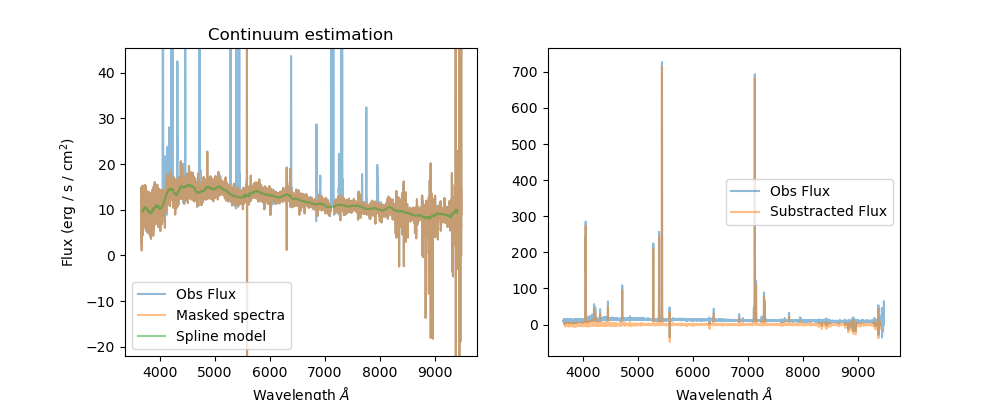

Saved continuum substracted data to: /Users/javieratoro/Desktop/thesis/proyecto 2024-2/cont_subs/J0328/cont_corr_J0328.csv


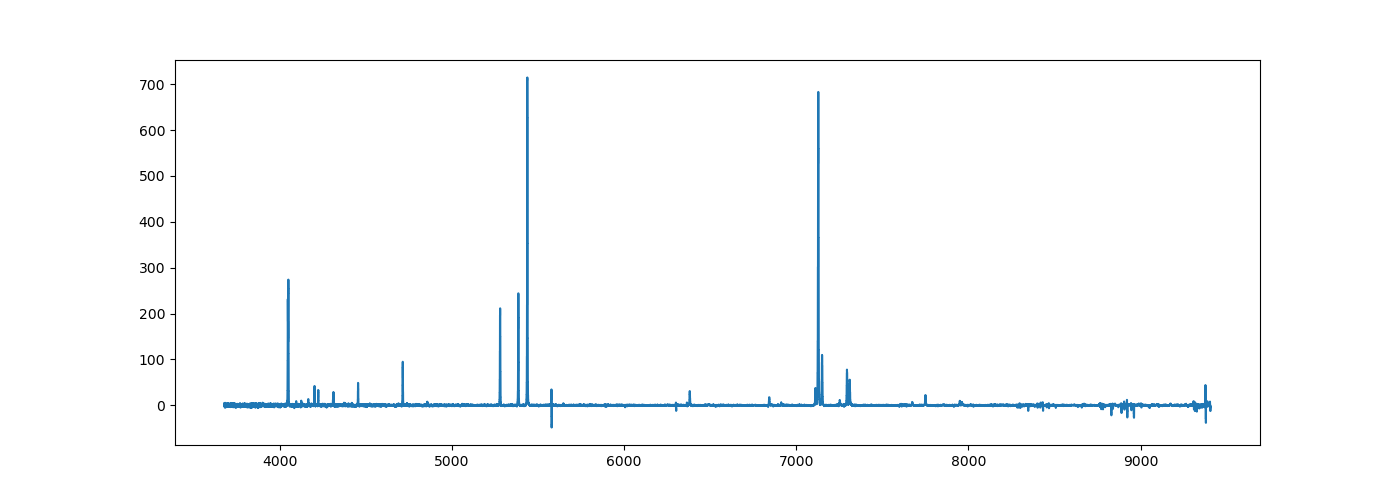

In [18]:
CONTINUUM_SUBSTRACT(J0328, plot=True)

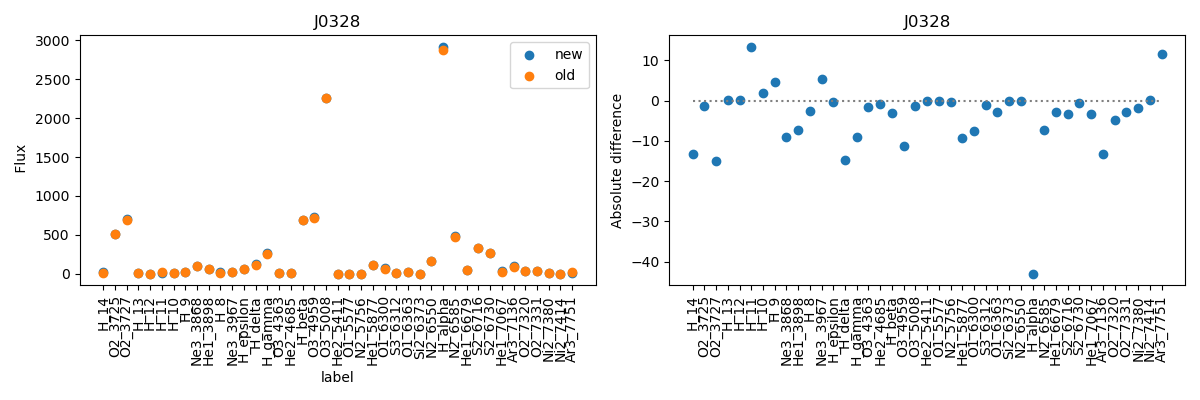

In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
fig, axs =plt.subplots(1,2, figsize=(12, 4))
old = pd.read_csv('/Users/javieratoro/Desktop/thesis/proyecto 2024-2/lines/J0328/J0328_model.csv')
new = pd.read_csv('/Users/javieratoro/Desktop/thesis/proyecto 2024-2/lines/J0328/J0328_model_parts.csv')
new = new[(new['name'] != 'S2_4068') & (new['name'] != 'S2_4076')]
axs[0].scatter(old['name'], new['flux'], marker="o", label='new')
axs[0].scatter(old['name'], old['flux'], marker="o", label='old')
# axs[0].plot(old['flux'], old['flux'], ls='dotted', color='grey')
axs[0].tick_params(axis='x', rotation=90)
axs[0].set_xlabel('label')
axs[0].set_ylabel(' Flux')
axs[0].set_title('J0328')
axs[0].legend()

axs[1].scatter(old['name'], (old['flux'].values-new['flux'].values), marker="o")
axs[1].tick_params(axis='x', rotation=90)
axs[1].plot(old['name'], np.zeros(len(old['flux'])), ls='dotted', color='grey')
axs[1].set_ylabel('Absolute difference')
axs[1].set_title('J0328')

plt.tight_layout()
plt.show()

Reading data for J0328
Using MW dust + Balmer abs corrected and continuum substracted data


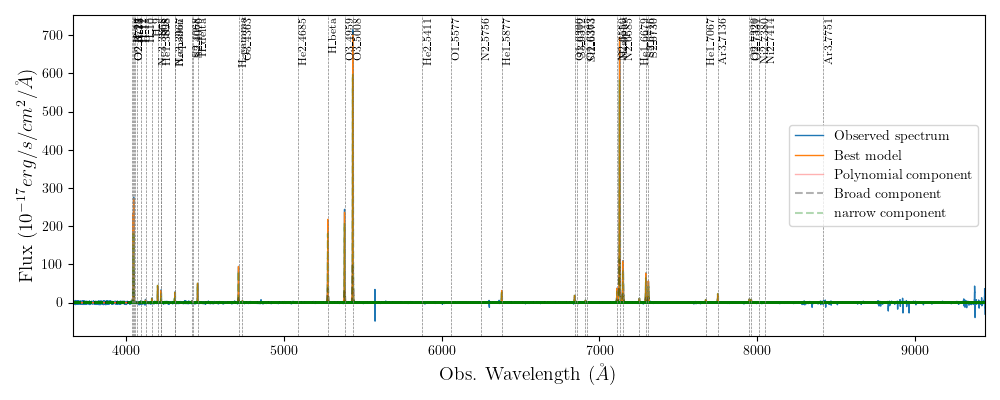

In [67]:
red = REDUC_LINES(J0328)
fit = red.fit_spectra(show_Plot=True)

In [76]:
linelist = red.spectra.linelist_dict
linelist['H_alpha']

6564.7

In [58]:
linelist['H_alpha'] = 6564.7
linelist['N2_6585'] = 6585

/var/folders/b3/z1vmt1t542ncmpppx7tfrqd80000gn/T/ipykernel_41378/1498331463.py:38: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig2.tight_layout()


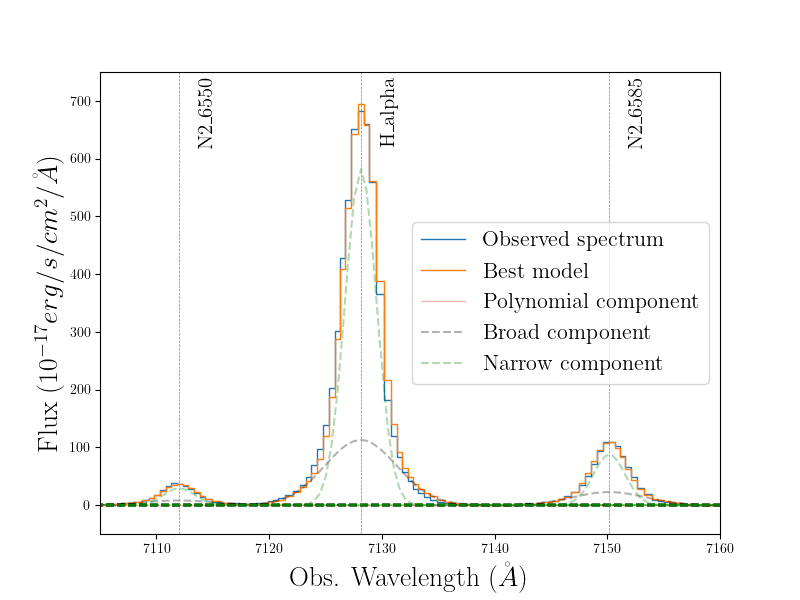

In [62]:
fig2, ax = plt.subplots(figsize=(8, 6))
comps = fit.eval_components(x=red.wave)
narrow_key = [key for key, _ in comps.items() if 'narrow' in key]
ax.plot(red.wave, red.flux, lw=1, drawstyle='steps-mid', label='Observed spectrum')
ax.plot(red.wave, fit.best_fit, lw=1, drawstyle='steps-mid',
        label='Best model')
ax.plot(red.wave, comps['polynomial'], 'r-', label='Polynomial component',
        lw=1, drawstyle='steps-mid', alpha=0.3)

broad_key = [key for key, _ in comps.items() if 'broad' in key]
for i, broad_line in enumerate(broad_key):
    if i == len(broad_key) - 1:
        ax.plot(red.wave, comps[broad_line] + comps['polynomial'], 'k--',
                label='Broad component', alpha=0.3)
    else:
        ax.plot(red.wave, comps[broad_line] + comps['polynomial'], 'k--',
                alpha=0.3)

for i, narrow_line in enumerate(narrow_key):
    if i == len(narrow_key) - 1:
        ax.plot(red.wave, comps[narrow_line] + comps['polynomial'], 'g--',
                label='Narrow component', alpha=0.3)
    else:
        ax.plot(red.wave, comps[narrow_line] + comps['polynomial'], 'g--',
                alpha=0.3)

for label in red.spectra.linelist_dict.keys():
    obs_lam = red.spectra.linelist_dict[label] * (1+red.spectra.redshift)
    ax.axvline(obs_lam, linestyle='--', linewidth=1, color='grey', lw=0.5)
    ax.text(obs_lam+1.5, 0.99, '\n'+label, rotation=90, ha='center', va='top',
            color='k', size=15, transform=ax.get_xaxis_transform())

ax.set_xlabel(r'Obs. Wavelength ($\AA$)', size=20)
ax.set_ylabel(r'Flux ($10^{-17} erg/s/cm^{2}/\AA$)', size=20)
ax.set_xlim(7105, 7160)
ax.set_ylim(-50, 750)
ax.legend(fontsize=16, frameon=True, loc='best')
fig2.tight_layout()

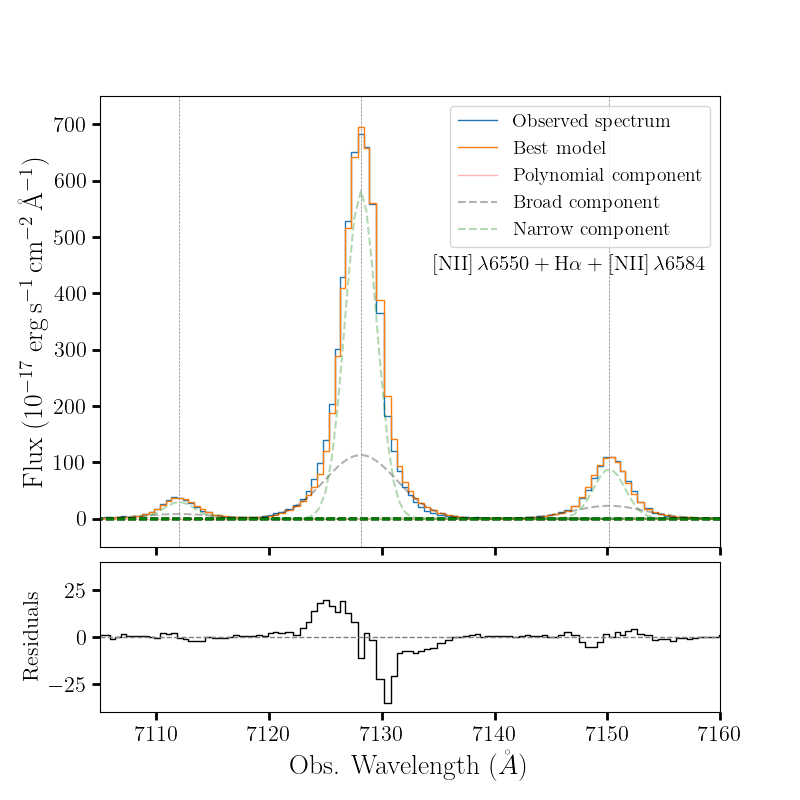

In [100]:
fig2, (ax, ax_res) = plt.subplots(
    2, 1, figsize=(8, 8),
    sharex=True,
    gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05}
)

comps = fit.eval_components(x=red.wave)

# --- Main spectrum ---
narrow_key = [key for key, _ in comps.items() if 'narrow' in key]

ax.plot(red.wave, red.flux, lw=1, drawstyle='steps-mid',
        label='Observed spectrum')

ax.plot(red.wave, fit.best_fit, lw=1, drawstyle='steps-mid',
        label='Best model')

ax.plot(red.wave, comps['polynomial'], 'r-',
        label='Polynomial component',
        lw=1, drawstyle='steps-mid', alpha=0.3)

broad_key = [key for key, _ in comps.items() if 'broad' in key]

for i, broad_line in enumerate(broad_key):
    ax.plot(red.wave, comps[broad_line] + comps['polynomial'],
            'k--',
            label='Broad component' if i == len(broad_key)-1 else None,
            alpha=0.3)

for i, narrow_line in enumerate(narrow_key):
    ax.plot(red.wave, comps[narrow_line] + comps['polynomial'],
            'g--',
            label='Narrow component' if i == len(narrow_key)-1 else None,
            alpha=0.3)


# --- Residuals ---
residuals = red.flux - fit.best_fit

ax_res.plot(red.wave, residuals,
            color='black',
            lw=1,
            drawstyle='steps-mid')

ax_res.axhline(0, color='grey', linestyle='--', lw=1)

ax_res.set_ylabel('Residuals', size=16)
ax_res.set_xlabel(r'Obs. Wavelength ($\AA$)', size=20)
ax_res.set_ylim(-40, 40)


# --- Emission line markers ---
for label in red.spectra.linelist_dict.keys():
    obs_lam = red.spectra.linelist_dict[label] * (1 + red.spectra.redshift)

    ax.axvline(obs_lam, linestyle='--',
               linewidth=0.5, color='grey')


ax.text(0.98, 0.65,
    r'$[\mathrm{NII}]\,\lambda6550 + \mathrm{H\alpha} +[\mathrm{NII}]\,\lambda6584$',
    transform=ax.transAxes,
    fontsize=15,
    color='k',
    ha='right',
    va='top'
)
# --- Formatting ---
ax.set_ylabel(r'Flux ($10^{-17}\ \mathrm{erg\,s^{-1}\,cm^{-2}\,\AA^{-1}}$)', size=20)

ax.set_xlim(7105, 7160)
ax.set_ylim(-50, 750)

ax.legend(fontsize=14, frameon=True, loc='upper right')
ax_res.tick_params(
    axis='both',
    which='major',
    labelsize=16,
    width=2,
    length=6
)
ax.tick_params(
    axis='both',
    which='major',
    labelsize=16,
    width=2,
    length=6, labelbottom=False
)


plt.show()

In [174]:
tm_dict = pd.read_csv('/Users/javieratoro/Desktop/thesis/proyecto 2024-2/lines/ratios/temden_lines1_parts.csv')
tm_dict_or = pd.read_csv('/Users/javieratoro/Desktop/thesis/proyecto 2024-2/nava_data/analogs/results/metals/temden_measured_final.csv')

In [140]:
tm_dict.keys()

Index(['Source', 'mass', 'z_red', 'z_blue', 'tOIII', 'tOIII_ERR', 'tNII',
       'tNII_ERR', 'ne_OIII', 'ne_OIII_ERR', 'tOII', 'tOII_ERR', 't(SII)_OIII',
       't(SII)_OIII_ERR', 'ne_OII', 'ne_OII_ERR', 'ne_SII', 'ne_SII_ERR',
       'tOII_ne', 'tOII_ne_ERR', 't(SII)_ne', 't(SII)_ne_ERR', '12_log_OH',
       '12_log_OH_ERR', '12_log_NH', '12_log_NH_ERR', 'log_NO', 'log_NO_ERR'],
      dtype='object')

In [175]:
tm_dict_or.keys()

Index(['galname', 'tOIII', 'tOIII_16', 'tOIII_84', 'tOII', 'tOII_16',
       'tOII_84', 'ne', 'ne_16', 'ne_84', 'tNII', 'tNII_16', 'tNII_84',
       'tSIII', 'tSIII_16', 'tSIII_84'],
      dtype='object')

In [176]:
# Literature

def B20(tempx, tempy):
    Tx = np.linspace(0.0, 100, 500)
    if (tempx == 'TO2' and tempy == 'TN2') or (tempy == 'TO2' and tempx == 'TN2'):
        Ty = (Tx - 1.203) / 1.004
    if (tempx == 'TS3' and tempy == 'TO3') or (tempy == 'TS3' and tempx == 'TO3'):
        Ty = (1.795 * Tx) - 8.167
    if (tempx == 'TS3' and tempy == 'TN2') or (tempy == 'TS3' and tempx == 'TN2'):
        Ty = (1.522 * Tx) - 4.576
    return Tx/10, Ty/10

def G92(tempx, tempy):
    Tx = np.linspace(0.0, 10.0, 500)
    if (tempx == 'TS3' and tempy == 'TO3') or (tempy == 'TS3' and tempx == 'TO3'):
        Ty = (0.83 * Tx) + 0.17
    if (tempx == 'TO2' and tempy == 'TO3') or (tempy == 'TO2' and tempx == 'TO3'):
        Ty = (0.7 * Tx) + 0.3
    return Tx, Ty

def PM17(tempx, tempy):
    Tx = np.linspace(0.0, 10.0, 500)
    if (tempx == 'TS2' and tempy == 'TO2') or (tempy == 'TS2' and tempx == 'TO2'):
        Ty = (0.71 * Tx) + 0.12
    if (tempx == 'TS3' and tempy == 'TO3') or (tempy == 'TS3' and tempx == 'TO3'):
        Ty = (1.19 * Tx) + 0.32
    if (tempx == 'TO2' and tempy == 'TO3') or (tempy == 'TO2' and tempx == 'TO3'):
        Ty = 2 * Tx / (1 + (0.8 * Tx))
    if (tempx == 'TN2' and tempy == 'TO3') or (tempy == 'TN2' and tempx == 'TO3'):
        Ty = 1.85 * Tx / (1 + (0.72 * Tx))
    return Tx, Ty

def R21(tempx, tempy):
    Tx = np.linspace(0.0, 10.0, 500)
    if (tempx == 'TO3' and tempy == 'TN2') or (tempx == 'TN2' and tempy == 'TO3'):
        Ty = (0.79 * Tx) + 0.16
    if (tempx == 'TS3' and tempy == 'TN2') or (tempx == 'TN2' and tempy == 'TS3'):
        Ty = (0.68 * Tx) + 0.28
    if (tempx == 'TO2' and tempy == 'TN2') or (tempx == 'TN2' and tempy == 'TO2'):
        Ty = (0.45 * Tx) + 0.36
    if (tempx == 'TO3' and tempy == 'TS3') or (tempx == 'TS3' and tempy == 'TO3'):
        Ty = (Tx - 0.36) / 0.63
    return Tx, Ty

def PM17_den(density=100):
    Tx = np.linspace(0.1, 10.0, 500)
    num = 1.2 + (0.002 * density) + (4.2 / density)
    den = 0.08 + (Tx**-1) + (0.003 * density) + (2.5 / density)
    Ty = num / den
    return Tx, Ty

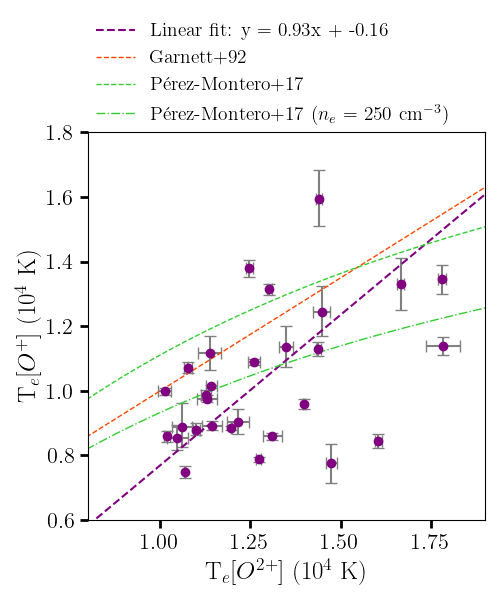

In [198]:
fig, ax = plt.subplots(1, 1, figsize=(5, 6))

all_x = pd.concat([tm_dict_or['tOIII'], tm_dict['tOIII']], ignore_index=True)
all_y = pd.concat([tm_dict_or['tOII'], tm_dict['tOII']], ignore_index=True)
x_det = all_x.sort_values().reset_index(drop=True)
y_det = all_y.sort_values().reset_index(drop=True)

slope, intercept = np.polyfit(x_det, y_det, 1)

x_line = np.linspace(0.8, 1.9, 100)
y_line = slope * x_line + intercept

ax.errorbar(tm_dict['tOIII'], tm_dict['tOII'], tm_dict['tOIII_ERR'], tm_dict['tOII_ERR'], fmt='o',color='purple',ecolor='gray',capsize=4,markersize=6)


xerr = [tm_dict_or['tOIII'] - tm_dict_or['tOIII_16'], tm_dict_or['tOIII_84'] - tm_dict_or['tOIII']]
yerr = [tm_dict_or['tOII'] - tm_dict_or['tOII_16'], tm_dict_or['tOII_84'] - tm_dict_or['tOII']]
ax.errorbar(tm_dict_or['tOIII'], tm_dict_or['tOII'], xerr=xerr, yerr=yerr,fmt='o',color='purple',ecolor='gray',capsize=4,markersize=6)

ax.plot(x_line, y_line, color='purple', linestyle='--', label=f'Linear fit: y = {slope:.2f}x + {intercept:.2f}')

ax.set_xlabel(r'T$_{e}[O^{2+}]$ ($10^{4}$ K)', fontsize=18)
ax.set_ylabel(r'T$_{e}[O^{+}]$ ($10^{4}$ K)', fontsize=18)
ax.set_xlim(0.8, 1.9)
ax.set_ylim(0.6, 1.8)
ax.plot(G92('TO3', 'TO2')[0], G92('TO3', 'TO2')[1],
              ls='--', lw=1, color='orangered', label='Garnett+92')
ax.plot(PM17('TO3', 'TO2')[0], PM17('TO3', 'TO2')[1],
              ls='--', lw=1, label='Pérez-Montero+17', color='limegreen')
ax.plot(PM17_den(250)[0], PM17_den(250)[1],
              ls='-.', lw=1, color='limegreen', label='Pérez-Montero+17 ($n_{e}$ = 250 cm$^{-3}$)')
ax.legend(loc=(0.0, 1.0), frameon=False, fontsize=14)

all_x = pd.concat([tm_dict_or['tOIII'], tm_dict['tOIII']], ignore_index=True)
all_y = pd.concat([tm_dict_or['tSIII'],  tm_dict['t(SII)_ne']], ignore_index=True)
x_det = all_x.sort_values().reset_index(drop=True)
y_det = all_y.sort_values().reset_index(drop=True)

slope, intercept = np.polyfit(x_det, y_det, 1)

x_line = np.linspace(0.8, 1.9, 100)
y_line = slope * x_line + intercept

# ax[1].errorbar(tm_dict['tOIII'], tm_dict['t(SII)_ne'], tm_dict['tOIII_ERR'], tm_dict['t(SII)_ne_ERR'],
#                fmt='o',color='purple',ecolor='gray',capsize=4,markersize=6)


xerr = [tm_dict_or['tOIII'] - tm_dict_or['tOIII_16'], tm_dict_or['tOIII_84'] - tm_dict_or['tOIII']]
yerr = [tm_dict_or['tSIII'] - tm_dict_or['tSIII_16'], tm_dict_or['tSIII_84'] - tm_dict_or['tSIII']]
# ax[1].errorbar(tm_dict_or['tOIII'], tm_dict_or['tSIII'], xerr=xerr, yerr=yerr,fmt='o',color='purple',ecolor='gray',capsize=4,markersize=6)

# ax[1].plot(x_line, y_line, color='purple', linestyle='--', label=f'Linear fit: y = {slope:.2f}x + {intercept:.2f}')

# ax[1].set_xlabel(r'T$_{e}[O^{2+}]$ ($10^{4}$ K)', fontsize=18)
# ax[1].set_ylabel(r'T$_{e}[S^{2+}]$ ($10^{4}$ K)', fontsize=18)
# ax[1].set_xlim(0.8, 1.9)
# ax[1].set_ylim(0.8, 2)
# ax[1].plot(G92('TO3', 'TS3')[0], G92('TO3', 'TS3')[1],
#               ls='--', lw=1, color='orangered')
# ax[1].plot(R21('TO3', 'TS3')[0], R21('TO3', 'TS3')[1],
#               ls='--', lw=1, color='gold', label='Rogers+21')

# ax[1].plot(B20('TO3', 'TS3')[0], B20('TO3', 'TS3')[1],
#               ls='--', lw=1, color='skyblue', label='Berg+20')
# ax[1].legend(loc=(0.0, 1.0), frameon=False, fontsize=14)

ax.tick_params(
    axis='both',
    which='major',
    labelsize=16,
    width=2,
    length=6
)

# ax[1].tick_params(
#     axis='both',
#     which='major',
#     labelsize=16,
#     width=2,
#     length=6
# )

plt.tight_layout()
plt.show()

In [180]:
from astropy.io import fits
izotov = fits.open('/Users/javieratoro/Desktop/thesis/proyecto 2024-2/nava_data/analogs/analysis/Izotov_2006.fits')[1].data
abun_mes = pd.read_csv('/Users/javieratoro/Desktop/thesis/proyecto 2024-2/nava_data/analogs/results/metals/abundance_measured_final.csv')


In [186]:
abun_mes[['log_OH', 'log_OH_16', 'log_OH_84']].head()

,log_OH,log_OH_16,log_OH_84
0,8.237354,8.223990,8.250817
1,8.081119,8.072452,8.089720
2,8.154166,8.131508,8.179418
3,7.978260,7.971075,7.985893
4,8.010618,7.989630,8.033542


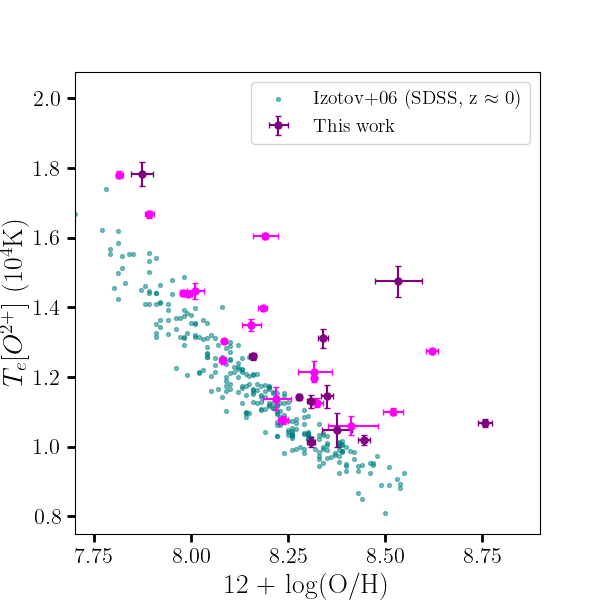

In [190]:
fig, axs = plt.subplots(1, 1, figsize=(6, 6))


all_x = pd.concat([tm_dict['12_log_OH'], abun_mes['log_OH']], ignore_index=True).sort_values().reset_index(drop=True)
all_y = pd.concat([tm_dict['tOIII'], tm_dict_or['tOIII']], ignore_index=True).sort_values().reset_index(drop=True)

yerr = [tm_dict_or['tOIII'] - tm_dict_or['tOIII_16'], tm_dict_or['tOIII_84'] - tm_dict_or['tOIII']]
xerr = [abun_mes['log_OH'] - abun_mes['log_OH_16'], abun_mes['log_OH_84'] - abun_mes['log_OH']]
plt.errorbar(abun_mes['log_OH'], tm_dict_or['tOIII'],
             xerr =xerr,
             yerr=yerr, ms=5,
            ls='', marker='o', capsize=2, color='magenta')

plt.errorbar(tm_dict['12_log_OH'], tm_dict['tOIII'],
             tm_dict['12_log_OH_ERR'], tm_dict['tOIII_ERR'], ms=5,
            ls='', marker='o', capsize=2, color='purple', label='This work')

plt.scatter(izotov['12+logO/H'], izotov['Te'], color='teal', alpha=0.5,
            s=8, label=r'Izotov+06 (SDSS, z $\approx$ 0)')

# plt.errorbar(OH, TeO2,
#              xerr =OH_err,
#              yerr= TeO2_err, ms=5, alpha=0.4,
#             ls='', marker='o', capsize=2, color='blue', label='Sanders+25 (AURORA, 1.64 < z < 5.18)')

plt.xlim(7.7, 8.9)
# plt.ylim(0.7, 2.0)
plt.tick_params(
    axis='both',
    which='major',
    labelsize=16,
    width=2,
    length=6
)
plt.xlabel('12 + log(O/H)', fontsize=20)
plt.ylabel(r'$T_{e}[O^{2+}$] ($10^{4}$K)', fontsize=20)
plt.legend(fontsize=14)

In [167]:
slope

np.float64(nan)

In [97]:
print(2 * (Z.z_chain.max() - Z.z_chain.min()) * red.spectra.linelist_dict['H_alpha']*(1+red.spectra.redshift) / (red.wave[1]-red.wave[0]))
print(2 * (Z.z_chain.max() - Z.z_chain.min()) * red.spectra.linelist_dict['H_beta']*(1+red.spectra.redshift) / (red.wave[1]-red.wave[0]))
print(2 * (Z.z_chain.max() - Z.z_chain.min()) * red.spectra.linelist_dict['O3_5008']*(1+red.spectra.redshift) / (red.wave[1]-red.wave[0]))
print(2 * (Z.z_chain.max() - Z.z_chain.min()) * red.spectra.linelist_dict['O3_4363']*(1+red.spectra.redshift) / (red.wave[1]-red.wave[0]))
print(2 * (Z.z_chain.max() - Z.z_chain.min()) * red.spectra.linelist_dict['N2_6550']*(1+red.spectra.redshift) / (red.wave[1]-red.wave[0]))
print(2 * (Z.z_chain.max() - Z.z_chain.min()) * red.spectra.linelist_dict['N2_6585']*(1+red.spectra.redshift) / (red.wave[1]-red.wave[0]))

2.7320622878892333
2.023728725866543
2.0843029586574215
1.8163696637706648
2.7258858091929303
2.740510635025302


In [14]:
red.fit_MC(numMC=100)

Calculating the first initial params
Starting MC iteration
Executed fit_MC in 1021.3591s


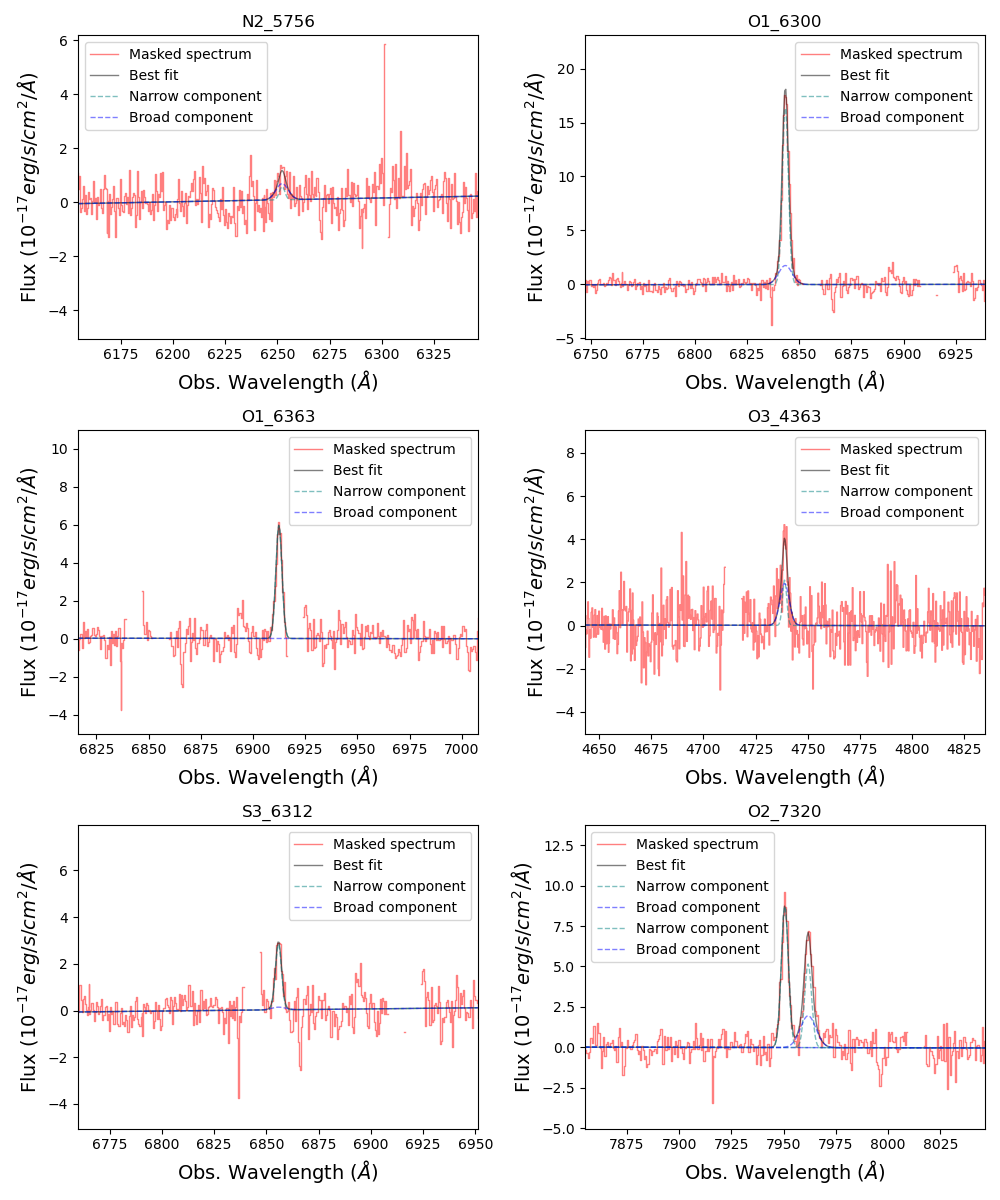

,sigma_v_narrow,sigma_v_broad,N2_5756_narrow_amplitude,N2_5756_broad_amplitude,O1_6300_narrow_amplitude,O1_6300_broad_amplitude,O1_6363_narrow_amplitude,O1_6363_broad_amplitude,O3_4363_narrow_amplitude,O3_4363_broad_amplitude,S3_6312_narrow_amplitude,S3_6312_broad_amplitude,O2_7320_narrow_amplitude,O2_7320_broad_amplitude,O2_7331_narrow_amplitude,O2_7331_broad_amplitude
0,63.754061,140.854241,1.636584,4.413063,60.224606,14.200677,21.976262,1.375955e-08,5.316452,10.829195,10.311297,0.92491,37.195257,0.000163,21.934686,18.462262


In [16]:
red.fit_auroral(red.wave, red.flux, showplot=True)

In [18]:
red.fit_MC_auroral(numMC=100)

/Users/javieratoro/Desktop/thesis/proyecto 2024-2/codes/lines.py:381: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  info = pd.concat([info, df], ignore_index=True)


Executed fit_MC_auroral in 23.3962s


,ID,mass,z,name,flux,fluxerr,narrow_flux,narrow_fluxerr,broad_flux,broad_fluxerr
0,J0328+0031,9.8,0.085829,N2_5756,6.235827,0.886785,1.696893,1.106856,4.664128,1.730940
1,J0328+0031,9.8,0.085829,O1_6363,22.131049,0.692379,21.660754,0.771214,0.000290,0.823561
2,J0328+0031,9.8,0.085829,O3_4363,16.208585,0.962959,5.656411,1.562708,10.509142,2.144390
3,J0328+0031,9.8,0.085829,S3_6312,11.472183,0.718517,10.295522,0.845462,1.093839,1.190044
4,J0328+0031,9.8,0.085829,O2_7320,37.193719,1.025846,36.978177,1.100862,0.000107,0.737429
5,J0328+0031,9.8,0.085829,O2_7331,40.611752,1.507594,21.882491,1.984958,18.730542,3.206952
6,J0328+0031,9.8,0.085829,O2_7320_7331,77.516308,1.767706,58.715753,2.339710,19.023238,3.216796
